# The missing halves: Tecplot, Elmer, FEBio, Patran, Femap, MFEM, libMesh, Z88 and Radioss

Added in v16.11.0:

- **Tecplot** reads and writes polygonal and polyhedral (`FEPOLYGON`/`FEPOLYHEDRON`) zones.
- **Elmer**'s partitioned writer adds the halo layer `ElmerGrid -halo` makes; **FEBio `.xplt`** reads edge variables.
- **MFEM** reads meshes and fields of any order as VTK Lagrange cells, non-conforming meshes as their leaves and parallel runs as one mesh, and writes Lagrange cells back.
- **Femap** writes output sets; **Patran** reads real P3/PATRAN and CUBIT exports, 9-node quads included.
- **libMesh** is written, and read compressed with its edge and shell-face sets.
- **Z88** reads and writes the whole deck and reads every element family's results.
- **Radioss** applies units and resolves boxes, generators and surfaces, and its **animation files** are a transient sequence.

Every file used here is in `tests/python/meshes/`.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None, lines=False):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4') or lines]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Tecplot polyhedral zones

`tecplot/plt/poly_3d.plt` was written with Tecplot's TecIO library: two `FEPOLYHEDRON` zones given face by face (each face's nodes and the elements on its left and right). Every element becomes a `polyhedron<N>` cell (N nodes) holding its faces, each face turned outward, and each zone is a cell region. `poly_3d.dat` is its ASCII twin and reads identically.

<meshio++ mesh object>
  Number of points: 34
  Number of cells:
    polyhedron8: 2
    polyhedron4: 1
    polyhedron10: 1
    polyhedron8: 1
  Cell sets: below, polyhedra
  Point data: T
  Cell data: P, tecplot:zone
same as the ASCII twin: True


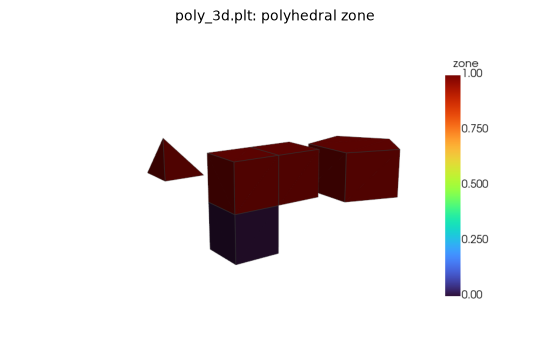

In [2]:
poly = mp.read(path('tecplot/plt', 'poly_3d.plt'))
print(poly)
twin = mp.read(path('tecplot/plt', 'poly_3d.dat'))
print('same as the ASCII twin:', [(c.type, str(c.data)) for c in poly.cells] == [(c.type, str(c.data)) for c in twin.cells])
grid = to_grid(poly, cell_data={'zone': region_array(poly)})
gallery([(grid, 'zone', 'poly_3d.plt: polyhedral zone', None)], ncols=1, size=(900, 520))

## MFEM at any order

`mfem/curved-hex-p3.mesh` is an MFEM reference cube refined, curved to order 3 on Gauss–Lobatto points and warped by MFEM, with an order-5 field `u`; the cells take the higher order, 5 (216 nodes a hexahedron). meshio++ numbers MFEM's degrees of freedom as MFEM does and interpolates each cell to the equispaced nodes of a VTK Lagrange cell, so the curved shape and the field are kept exactly; the mesh writes to `.vtu` as it is, and ParaView draws it curved.

[('VTK_LAGRANGE_HEXAHEDRON', 8, 216), ('VTK_LAGRANGE_QUADRILATERAL', 24, 36)]


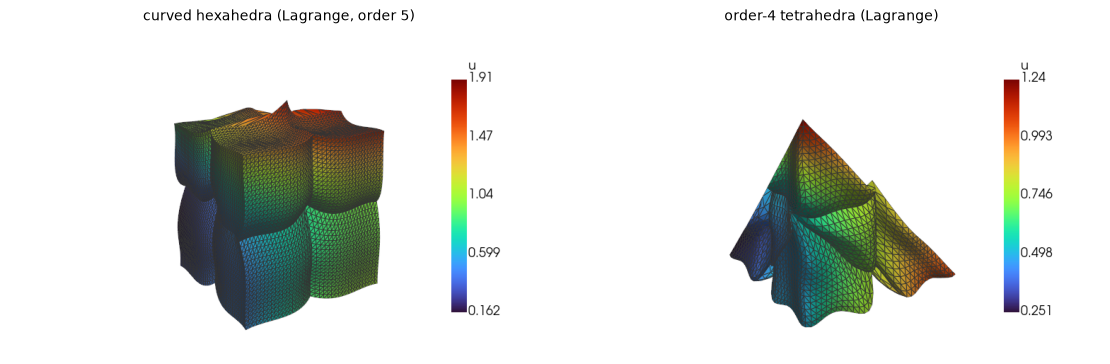

In [3]:
hexp3 = mp.mfem.read(path('mfem', 'curved-hex-p3.mesh'), {'u': path('mfem', 'curved-hex-p3.u.gf')})
print([(c.type, len(c.data), len(c.data[0])) for c in hexp3.cells])
target = os.path.join(TMP, 'hex_p3.vtu')
mp.write(target, hexp3)
lagrange = pv.read(target)
tet = mp.mfem.read(path('mfem', 'curved-tet-p4.mesh'), {'u': path('mfem', 'curved-tet-p4.u.gf')})
mp.write(os.path.join(TMP, 'tet_p4.vtu'), tet)
gallery([(curved(lagrange, 3), 'u', 'curved hexahedra (Lagrange, order 5)', None),
         (curved(pv.read(os.path.join(TMP, 'tet_p4.vtu')), 3), 'u', 'order-4 tetrahedra (Lagrange)', None)],
        ncols=2)

Writing Lagrange cells back gives an `H1_3D_P<order>` nodes space (here order 5) that MFEM reads to the same geometry. A **non-conforming** mesh (`amr-quad.mesh`, `MFEM NC mesh`) is read as its leaf elements, and a **parallel** run (`parallel/star-p2.pmesh.000000`, four ranks with their communication groups) as one mesh whose `partition:part` is each cell's rank.

H1_3D_P5
leaves: [('quad', 28), ('line', 16)] | parallel ranks: [0, 1, 2, 3]


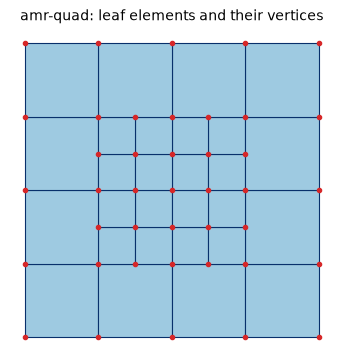

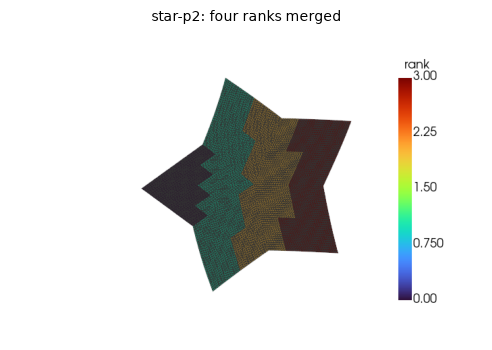

In [4]:
back = os.path.join(TMP, 'hex_p3.mesh')
mp.mfem.write(back, hexp3)
print(open(back).read().split('FiniteElementCollection:')[1].split()[0])
nc = mp.read(path('mfem', 'amr-quad.mesh'))
par = mp.mfem.read(path('mfem/parallel', 'star-p2.pmesh.000000'), {'u': path('mfem/parallel', 'star-p2.u.000000')})
print('leaves:', [(c.type, len(c.data)) for c in nc.cells], '| parallel ranks:', sorted(set(np.concatenate(par.cell_data['partition:part']).tolist())))
# The leaves drawn as polygons: a hanging node sits in the middle of its neighbour's edge.
from matplotlib.collections import PolyCollection
fig, ax = plt.subplots(figsize=(4.2, 4.2))
quads = [c.data for c in nc.cells if c.type == 'quad'][0]
ax.add_collection(PolyCollection(nc.points[quads][:, :, :2], facecolor='#9ecae1', edgecolor='#08306b', linewidth=0.8))
ax.plot(*nc.points[:, :2].T, 'o', color='#d62728', markersize=3)
ax.set_aspect('equal'); ax.autoscale(); ax.set_title('amr-quad: leaf elements and their vertices', fontsize=10); ax.axis('off')
plt.show()
gallery([(curved(to_grid(par, cell_data={'rank': par.cell_data['partition:part']})), 'rank', 'star-p2: four ranks merged', None)],
        ncols=1, view=(0, 0, 1), size=(700, 460))

## Elmer halo elements and FEBio edge variables

`mp.elmer.write(..., halo=True)` adds to each part the elements of other parts that touch it by a whole side, written `id/owner` as ElmerGrid does, so a discontinuous Galerkin solver finds its neighbours. `febio/xplt/xplt_edge.xplt` (FEBio 4.12) has an edge with the `edge contact gap` variable: the edge is a `line` block with its own cell region.

In [5]:
cube = mp.Mesh(*[(np.array([[x, y, z] for z in range(3) for y in range(3) for x in range(3)], float))], [
    ('hexahedron', np.array([[i + 3 * j + 9 * k + o for o in (0, 1, 4, 3, 9, 10, 13, 12)]
                             for k in range(2) for j in range(2) for i in range(2)]))])
cube.cell_data['partition:part'] = [np.array([0, 1, 0, 1, 0, 1, 0, 1])]
out = os.path.join(TMP, 'halo')
mp.elmer.write(out, cube, halo=True)
for part in (1, 2):
    rows = open(os.path.join(out, 'partitioning.2', f'part.{part}.elements')).read().split('\n')
    print(f'part {part}:', len([r for r in rows if r.strip()]), 'elements,', sum('/' in r.split()[0] for r in rows if r.strip()), 'of them halo')
edge = mp.read(path('febio/xplt', 'xplt_edge.xplt'), time_step=-1)
print([(c.type, len(c.data)) for c in edge.cells], [r.name for r in edge.regions if r.kind == 'cell'][:4])

part 1: 8 elements, 4 of them halo
part 2: 8 elements, 4 of them halo
[('hexahedron', 2), ('quad', 2), ('line', 2)] ['bar', 'ridge', 'top']


## Patran and Femap

`patran/real/tahoe_square.pat` is a P3/PATRAN 3.0 export from Tahoe's benchmarks: its named components (packet 21) become regions. The Femap writer now writes output sets: a point array becomes a nodal output vector (one per component) and a cell array an elemental one, read back as the step's data.

{('point', 'BOTTOM'): 4, ('point', 'CORNER1'): 1, ('point', 'CORNER2'): 1, ('point', 'SQUARE'): 16, ('point', 'TOP'): 4, ('cell', 'SQUARE'): 9}
Femap output set: 0.5 T equal: True


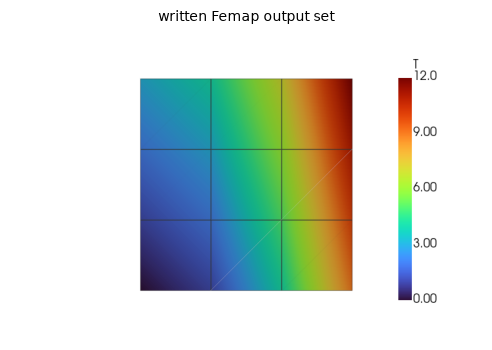

In [6]:
square = mp.read(path('patran/real', 'tahoe_square.pat'))
print({(r.kind, r.name): len(r.entries) for r in square.regions})
square.point_data['T'] = square.points[:, 0] ** 2 + square.points[:, 1]
square.field_data['meshio:time'] = np.array([0.5])
neu = os.path.join(TMP, 'square.neu')
mp.write(neu, square)
again = mp.read(neu)
print('Femap output set:', float(np.ravel(again.field_data['meshio:time'])[0]), 'T equal:', np.allclose(again.point_data['T'], square.point_data['T']))
gallery([(to_grid(again, point_data={'T': again.point_data['T']}), 'T', 'written Femap output set', None)], ncols=1, view=(0, 0, 1), size=(700, 460))

## libMesh, written and compressed

`libmesh/edges_shell.xda` has a HEX20 and a QUAD8 shell, two edge sets (read as `line3` cells in `<name>:edge` regions) and both shell faces (`<name>:shellface0`/`1` regions). It is written back as XDR, gzip-compressed, and reads the same.

In [7]:
lm = mp.read(path('libmesh', 'edges_shell.xda'))
print([(c.type, len(c.data)) for c in lm.cells])
print(sorted(r.name for r in lm.regions))
gz = os.path.join(TMP, 'edges_shell.xdr.gz')
mp.write(gz, lm)
print('round trip:', sorted(r.name for r in mp.read(gz).regions) == sorted(r.name for r in lm.regions))

[('hexahedron20', 1), ('quad8', 1), ('line3', 2)]
['axis:edge', 'bottom', 'boundary_12:edge', 'boundary_21:shellface1', 'front:shellface0', 'skin', 'subdomain_1']
round trip: True


## Z88, the whole deck

`z88/frame` is a 3-D frame of beams and a truss that Z88OS's solver ran: the constraints, materials, element parameters and integration orders are read beside the structure, and `z88o3.txt`'s beam and truss stresses and `z88o4.txt`'s nodal forces with the results. `z88/plate` shows the plate moments. Writing the mesh writes every input file back, and Z88R solves it to the same displacements.

beam/truss SIGXX: [0.209, -9.689, -9.716, 13.41]
sum of nodal forces: [0.0003, 0.0, 0.0]
written: ['51.txt', 'z88elp.txt', 'z88i1.txt', 'z88i2.txt', 'z88int.txt', 'z88mat.txt']


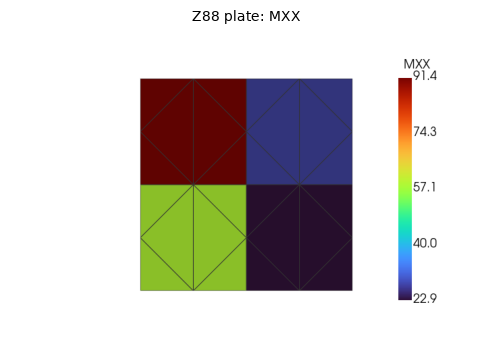

In [8]:
frame = mp.read(path('z88/frame', 'z88i1.txt'))
print('beam/truss SIGXX:', np.round(frame.cell_data['SIGXX'][0], 3).tolist())
print('sum of nodal forces:', np.round(frame.point_data['F'].sum(axis=0)[:3], 6).tolist())
deck = os.path.join(TMP, 'z88deck')
os.makedirs(deck, exist_ok=True)
mp.write(os.path.join(deck, 'z88i1.txt'), frame)
print('written:', sorted(os.listdir(deck)))
plate = mp.read(path('z88/plate', 'z88i1.txt'))
gallery([(to_grid(plate, cell_data={'MXX': plate.cell_data['MXX']}), 'MXX', 'Z88 plate: MXX', None)], ncols=1, view=(0, 0, 1), size=(700, 460))

## Radioss animation files

`radioss_anim/cubeA001` and `cubeA002` are two states of a small model with every section an animation file can hold. Each file is one state with its time in the file, so a glob over the run is a sequence. The second state has moved nodes and one deleted element (`radioss:alive` 0).

cubeA001 time 0.0 (from the file)
cubeA002 time 0.5 (from the file)
alive: [1, 1, 1, 1, 1, 0, 1, 1, 1]


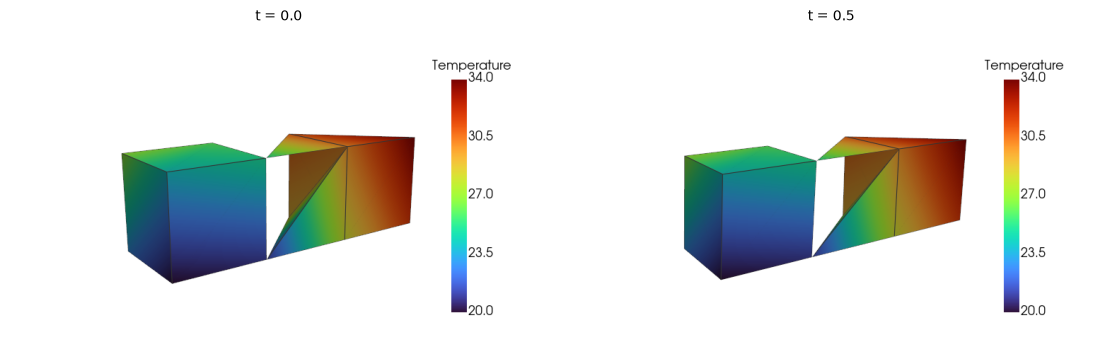

In [9]:
for entry in mp.sequence_entries(path('radioss_anim', 'cubeA*')):
    print(os.path.basename(entry['path']), 'time', entry['time'], '(from the', entry['time_source'] + ')')
states = [m for _, m in mp.read_sequence(path('radioss_anim', 'cubeA*'))]
last = states[-1]
print('alive:', np.concatenate(last.cell_data['radioss:alive']).tolist())
gallery([(to_grid(s, point_data={'Temperature': s.point_data['Temperature']}), 'Temperature',
          f"t = {float(s.field_data['meshio:time'][0])}", None) for s in states], ncols=2)